In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Keeping the seed fixed so the runs stay reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train shape:", train_tabular_df.shape)
print("Test shape:", test_tabular_df.shape)
train_tabular_df.head()

Train shape: (240, 13)
Test shape: (80, 13)


,sample_id,sleep_hours,study_hours,attendance_pct,stress_score,caffeine_cups,exercise_minutes,screen_time_hours,assignment_delay_days,social_minutes,mood_score,label,label_id
0,train_0000,8.18,1.46,96.50,29.41,0.00,31.98,4.65,0.18,59.80,7.15,low_risk,0
1,train_0001,7.33,4.78,85.40,56.27,2.13,21.41,6.44,0.54,55.54,6.25,moderate_risk,1
2,train_0002,5.49,4.82,84.34,68.45,2.50,14.48,8.14,3.57,34.95,4.93,high_risk,2
3,train_0003,5.88,6.09,64.93,79.86,4.23,19.29,8.86,4.16,5.11,3.65,critical_risk,3
4,train_0004,8.45,3.04,88.01,22.32,1.08,47.19,5.55,0.72,68.15,8.07,low_risk,0


In [4]:
# Turning label names into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [5]:
# Keeping only numeric feature columns
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

X_train_full = train_tabular_df[numeric_feature_columns].values
y_train_full = train_tabular_df["label_id"].values

X_test = test_tabular_df[numeric_feature_columns].values
y_test = test_tabular_df["label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [6]:
# This is a simple custom dense layer instead of using the built-in Dense directly
class MyDense(layers.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

In [7]:
# This custom layer adds a little Gaussian noise during training
class AddGaussianNoise(layers.Layer):
    def __init__(self, stddev=0.05):
        super().__init__()
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs + noise
        return inputs

In [8]:
# This is a simple custom layer normalization layer
class MyLayerNormalization(layers.Layer):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True
        )
        self.beta = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta

In [9]:
# This is a small residual block built using the custom dense layer
class ResidualBlock(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.dense_1 = MyDense(units, activation="relu")
        self.norm_1 = MyLayerNormalization()
        self.dense_2 = MyDense(units, activation=None)
        self.norm_2 = MyLayerNormalization()
        self.activation = layers.ReLU()

    def call(self, inputs, training=None):
        x = self.dense_1(inputs)
        x = self.norm_1(x)
        x = self.dense_2(x)
        x = self.norm_2(x)
        return self.activation(inputs + x)

In [10]:
# This is a regular baseline model for comparison
def build_baseline_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
# This custom model uses the custom layers, Gaussian noise, and residual blocks
class ResidualClassifier(keras.Model):
    def __init__(self, num_classes):
        super().__init__()
        self.input_proj = MyDense(64, activation="relu")
        self.noise = AddGaussianNoise(stddev=0.05)
        self.res_block_1 = ResidualBlock(64)
        self.res_block_2 = ResidualBlock(64)
        self.classifier = MyDense(num_classes, activation="softmax")

    def call(self, inputs, training=None):
        x = self.input_proj(inputs)
        x = self.noise(x, training=training)
        x = self.res_block_1(x, training=training)
        x = self.res_block_2(x, training=training)
        return self.classifier(x)

In [12]:
# Building and compiling the custom residual model
custom_model = ResidualClassifier(num_classes=len(label_to_index))

custom_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Training the baseline model
baseline_model = build_baseline_model(X_train.shape[1])

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print("Baseline Test Accuracy:", round(baseline_test_acc, 4))

Baseline Test Accuracy: 0.925


In [14]:
# Training the custom residual model
history_custom = custom_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

custom_test_loss, custom_test_acc = custom_model.evaluate(X_test, y_test, verbose=0)
print("Custom Residual Model Test Accuracy:", round(custom_test_acc, 4))

Custom Residual Model Test Accuracy: 0.9625


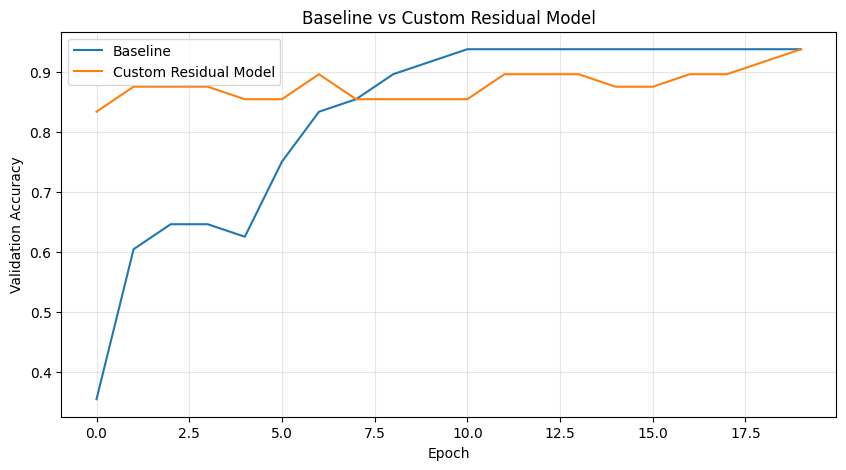

In [15]:
# Comparing the baseline and custom model validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_custom.history["val_accuracy"], label="Custom Residual Model")
plt.title("Baseline vs Custom Residual Model")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Looking at a few predictions from the custom model
sample_predictions = custom_model.predict(X_test[:8], verbose=0)
predicted_classes = np.argmax(sample_predictions, axis=1)

for i in range(8):
    print("True Label     :", index_to_label[y_test[i]])
    print("Predicted Label:", index_to_label[predicted_classes[i]])
    print("-" * 50)

True Label     : low_risk
Predicted Label: low_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------
True Label     : low_risk
Predicted Label: low_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------


In [17]:
# Final summary so the comparison is easy to explain in the video
print("Colab 8 Results Summary")
print("-" * 45)
print(f"Baseline Model Accuracy         : {baseline_test_acc:.4f}")
print(f"Custom Residual Model Accuracy  : {custom_test_acc:.4f}")

Colab 8 Results Summary
---------------------------------------------
Baseline Model Accuracy         : 0.9250
Custom Residual Model Accuracy  : 0.9625


### Final Observation

In this notebook, I focused on building custom neural network components in TensorFlow. I created a custom dense layer, a custom Gaussian noise layer, a custom layer normalization layer, and then used them inside residual blocks to build a custom residual classifier. I compared this model against a simpler baseline model to understand how custom layers and residual-style design can be used to build more flexible deep learning models.